## Architecture #3 + OG Neutrosophic Loss (Low Data Regime)

##### 1. Imports

In [1]:
import numpy as np
import pandas as pd

from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.layers import ( 
    SpatialDropout1D, Embedding, Bidirectional, 
    LSTM, Dense, Dropout, 
    BatchNormalization, Input, Layer,
    GlobalAveragePooling1D, GlobalMaxPooling1D, Concatenate,
    Attention, MultiHeadAttention, LayerNormalization
)

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

2026-02-06 08:20:06.041322: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770366006.232120      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770366006.283139      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
tf.keras.utils.set_random_seed(42)

##### 2. Load Dataset (20%)

In [3]:
file = r"/kaggle/input/bias-detection-dataset-processed/balanced_bias_data_parquet.parquet"
balanced_df = pd.read_parquet(file)
balanced_df = balanced_df.sample(frac=0.4, random_state=42).reset_index(drop=True)

print(balanced_df)
print("\nColumns:", balanced_df.columns)
print("\nShape:", balanced_df.shape)

         Unnamed: 0                                               text  \
0            907743  i cant breathe! just call me hott stuffy! lol....   
1           1758411  the cma is dominated by social justice warrior...   
2           2316667  one thing trump has done for the better is to ...   
3           1276711  the compensation for the 11 deaths in his fami...   
4           2242836  so to summarizennmischaracterization lie lie l...   
...             ...                                                ...   
1142716     2465784  the odd denigrating tone of the articles title...   
1142717     2581955  genocides nn i think we must not minimize the ...   
1142718      323457  cliff eyland article nnheyndidnt seem notable ...   
1142719      292980  peaugh okay...but u burried it? our team shoul...   
1142720     1452961  they havent released the name of the dog pendi...   

                                              biased_words  bias  sentiment  \
0                               

##### 3. Tokenisation & Padding

In [4]:
MAX_VOCAB = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(balanced_df['text'])

X = tokenizer.texts_to_sequences(balanced_df['text'])
X = pad_sequences(X, maxlen=MAX_LEN, padding='post', truncating='post')
print(X.shape)

(1142721, 100)


##### 4. Train-Test Split

In [5]:
y = balanced_df[['bias', 'sentiment', 'toxic']]
print(y)
print(y.shape)

         bias  sentiment  toxic
0           1          2      1
1           2          2      0
2           0          2      1
3           0          0      0
4           2          1      1
...       ...        ...    ...
1142716     0          2      0
1142717     0          2      0
1142718     1          1      0
1142719     1          2      0
1142720     1          1      1

[1142721 rows x 3 columns]
(1142721, 3)


In [6]:
# split for training, testing and validation as 80%-10%-10%.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size=0.5, random_state=42, stratify=y_test)

In [7]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("X_valid:", X_valid.shape)

y_train_bias = y_train["bias"].to_numpy()
y_train_sentiment = y_train["sentiment"].to_numpy()
y_train_toxic = y_train["toxic"].to_numpy()

print("y_train_bias:", y_train_bias.shape)
print("y_train_sentiment:", y_train_sentiment.shape)
print("y_train_toxic:", y_train_toxic.shape)

y_test_bias = y_test["bias"].to_numpy()
y_test_sentiment = y_test["sentiment"].to_numpy()
y_test_toxic = y_test["toxic"].to_numpy()

print("y_test_bias:", y_test_bias.shape)
print("y_test_sentiment:", y_test_sentiment.shape)
print("y_test_toxic:", y_test_toxic.shape)

y_valid_bias = y_valid["bias"].to_numpy()
y_valid_sentiment = y_valid["sentiment"].to_numpy()
y_valid_toxic = y_valid["toxic"].to_numpy()

print("y_valid_bias:", y_valid_bias.shape)
print("y_valid_sentiment:", y_valid_sentiment.shape)
print("y_valid_toxic:", y_valid_toxic.shape)

X_train: (799904, 100)
X_test: (171408, 100)
X_valid: (171409, 100)
y_train_bias: (799904,)
y_train_sentiment: (799904,)
y_train_toxic: (799904,)
y_test_bias: (171408,)
y_test_sentiment: (171408,)
y_test_toxic: (171408,)
y_valid_bias: (171409,)
y_valid_sentiment: (171409,)
y_valid_toxic: (171409,)


In [8]:
y_train_bias_oh = to_categorical(y_train_bias, num_classes=3)
y_valid_bias_oh = to_categorical(y_valid_bias, num_classes=3)
y_test_bias_oh = to_categorical(y_test_bias, num_classes=3)

y_train_sentiment_oh = to_categorical(y_train_sentiment, num_classes=3)
y_valid_sentiment_oh = to_categorical(y_valid_sentiment, num_classes=3)
y_test_sentiment_oh = to_categorical(y_test_sentiment, num_classes=3)

y_train_toxic_oh = to_categorical(y_train_toxic, num_classes=2)
y_valid_toxic_oh = to_categorical(y_valid_toxic, num_classes=2)
y_test_toxic_oh = to_categorical(y_test_toxic, num_classes=2)

##### 5. Neutrosophic Loss Function

In [9]:
def neutrosophic_loss(alpha, beta, gamma):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_sigmoid = tf.clip_by_value(tf.nn.sigmoid(y_pred), 1e-7, 1-1e-7)

        truth = -y_true * tf.math.log(y_sigmoid)
        falsity = -(1 - y_true) * tf.math.log(1 - y_sigmoid)
        indeterminacy = 1.0 - tf.abs(y_sigmoid - 0.5) * 2.0

        neutro_loss = alpha * truth + beta * falsity + gamma * indeterminacy
        return tf.reduce_mean(neutro_loss)
    return loss_fn

##### 6. Model Architecture

In [10]:
def build_model(alpha, beta, gamma):
    MAX_VOCAB = 10000
    input_layer = Input(shape=(100,))
    
    x = Embedding(MAX_VOCAB, 512, trainable=True)(input_layer)
    
    x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3))(x)
    x = LayerNormalization()(x)
    
    x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.3))(x)
    x = LayerNormalization()(x)
    
    # Multi-head attention
    attn = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    
    # Dual pooling
    avg_pool = GlobalAveragePooling1D()(attn)
    max_pool = GlobalMaxPooling1D()(attn)
    x = Concatenate()([avg_pool, max_pool])
    
    x = Dense(256, activation="gelu")(x)
    x = Dropout(0.4)(x)
    
    x = Dense(128, activation="gelu", kernel_regularizer=l2(1e-4))(x)

    neutro = Dense(128, activation="tanh", name="neutro_latent")(x)
    
    # Output heads
    output_b = Dense(3, activation='linear', name='output_b')(neutro)
    output_s = Dense(3, activation='linear', name='output_s')(neutro)
    output_t = Dense(2, activation='linear', name='output_t')(neutro)
    
    model = Model(inputs=input_layer, outputs=[output_b, output_s, output_t])

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=1e-3,
        decay_steps=10000,
        decay_rate=0.9
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(
        optimizer=optimizer,
        loss={
            "output_b": neutrosophic_loss(alpha, beta, gamma),
            "output_s": neutrosophic_loss(alpha, beta, gamma),
            "output_t": neutrosophic_loss(alpha, beta, gamma),
        },
        metrics={
            "output_b": tf.keras.metrics.CategoricalAccuracy(name="acc"),
            "output_s": tf.keras.metrics.CategoricalAccuracy(name="acc"),
            "output_t": tf.keras.metrics.CategoricalAccuracy(name="acc")
        }
    )
    return model

##### 6. Model Training

In [11]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model = build_model(0.9391, 0.6620, 0.1349)

history = model.fit(
    X_train,
    {
        "output_b": y_train_bias_oh,
        "output_s": y_train_sentiment_oh,
        "output_t": y_train_toxic_oh
    },
    validation_data=(
        X_valid,
        {
            "output_b": y_valid_bias_oh,
            "output_s": y_valid_sentiment_oh,
            "output_t": y_valid_toxic_oh
        }
    ),
    epochs=10,
    batch_size=512,
    verbose=1,
    callbacks=[early_stopping]
)

I0000 00:00:1770366085.599596      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/10


I0000 00:00:1770366099.793437     110 cuda_dnn.cc:529] Loaded cuDNN version 90300


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 274s 166ms/step - loss: 1.1397 - output_b_acc: 0.7317 - output_b_loss: 0.3427 - output_s_acc: 0.7344 - output_s_loss: 0.3471 - output_t_acc: 0.7514 - output_t_loss: 0.4372 - val_loss: 0.7194 - val_output_b_acc: 0.8493 - val_output_b_loss: 0.2227 - val_output_s_acc: 0.8953 - val_output_s_loss: 0.1709 - val_output_t_acc: 0.8374 - val_output_t_loss: 0.3193
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 256s 164ms/step - loss: 0.7051 - output_b_acc: 0.8513 - output_b_loss: 0.2198 - output_s_acc: 0.8985 - output_s_loss: 0.1682 - output_t_acc: 0.8420 - output_t_loss: 0.3115 - val_loss: 0.6692 - val_output_b_acc: 0.8584 - val_output_b_loss: 0.2086 - val_output_s_acc: 0.9087 - val_output_s_loss: 0.1542 - val_output_t_acc: 0.8475 - val_output_t_loss: 0.3023
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 258s 165ms/step - loss: 0.6499 - output_b_acc: 0.8626 - output_b_loss: 0.2041 - output_s_acc: 0.9100 - output_s_loss: 0.1513 - output_t_acc: 0.8544 - output_t_loss: 0.2906 -

##### 7. Model Evaluation

1340/1340 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step
====================== Bias Task ======================
Accuracy: 0.8754
                 precision    recall  f1-score   support

  Highly Biased       0.91      0.89      0.90     49096
        Neutral       0.87      0.90      0.89     53460
Slightly Biased       0.85      0.85      0.85     68852

       accuracy                           0.88    171408
      macro avg       0.88      0.88      0.88    171408
   weighted avg       0.88      0.88      0.88    171408


==================== Sentiment Task ====================
Accuracy: 0.9180
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.89     37672
     Neutral       0.94      0.90      0.92     59020
    Positive       0.92      0.95      0.94     74716

    accuracy                           0.92    171408
   macro avg       0.91      0.91      0.91    171408
weighted avg       0.92      0.92      0.92    171408


====================== 

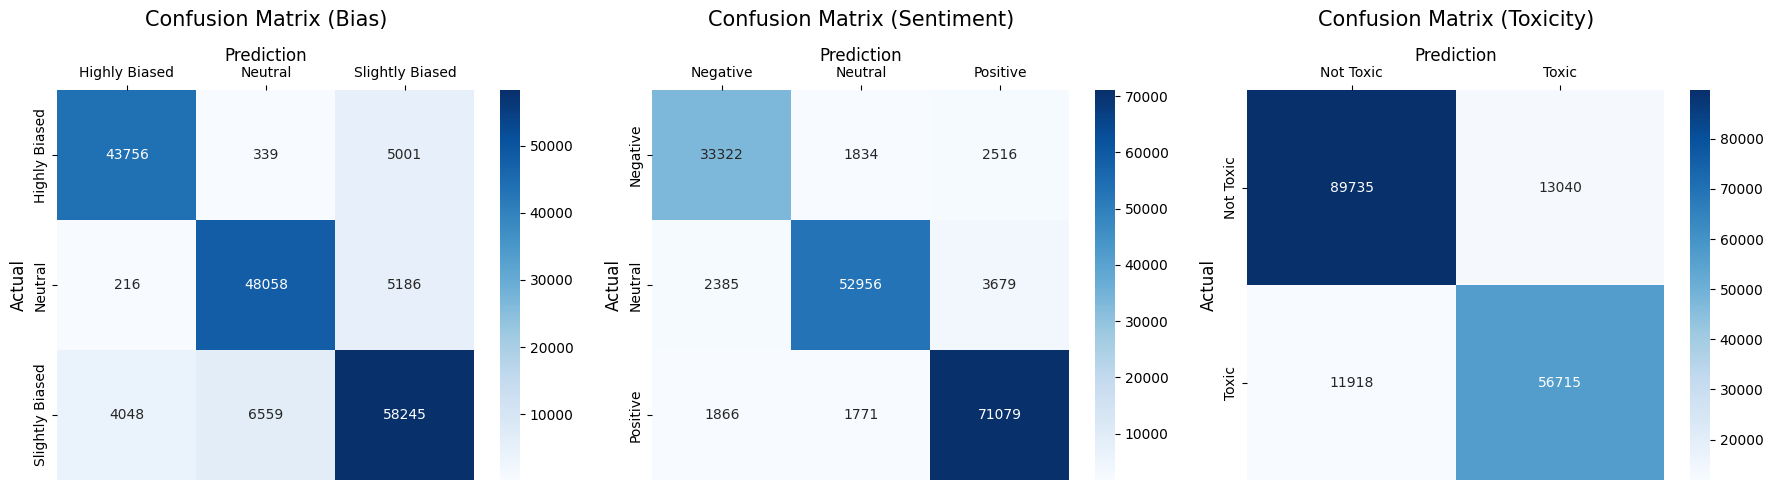

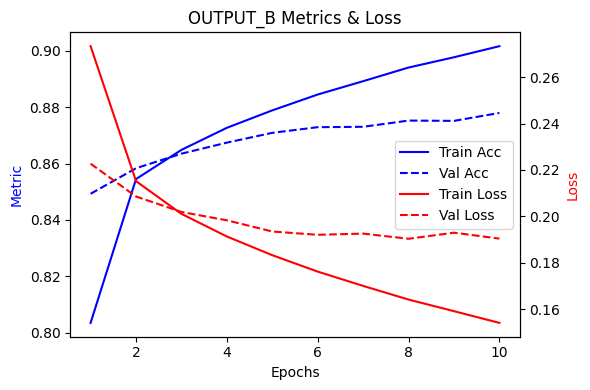

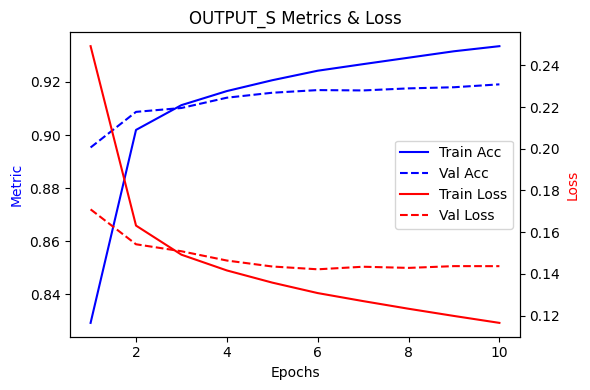

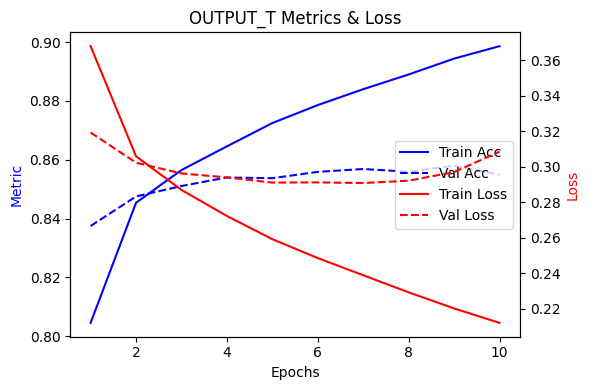


--------------------------------------------------------------------------



In [12]:
y_pred_probs = model.predict(X_test, batch_size=128)

y_pred_bias = np.argmax(y_pred_probs[0], axis=1)
y_pred_sentiment = np.argmax(y_pred_probs[1], axis=1)
y_pred_toxic = np.argmax(y_pred_probs[2], axis=1)

y_true_bias = np.argmax(y_test_bias_oh, axis=1)
y_true_sentiment = np.argmax(y_test_sentiment_oh, axis=1)
y_true_toxic = np.argmax(y_test_toxic_oh, axis=1)

bias_labels = ['Highly Biased', 'Neutral', 'Slightly Biased']
sentiment_labels = ['Negative', 'Neutral', 'Positive']
toxicity_labels = ['Not Toxic', 'Toxic']

print("====================== Bias Task ======================")
print(f"Accuracy: {accuracy_score(y_true_bias, y_pred_bias):.4f}")
print(classification_report(y_true_bias, y_pred_bias, target_names=bias_labels))

print("\n==================== Sentiment Task ====================")
print(f"Accuracy: {accuracy_score(y_true_sentiment, y_pred_sentiment):.4f}")
print(classification_report(y_true_sentiment, y_pred_sentiment, target_names=sentiment_labels))

print("\n====================== Toxic Task ======================")
print(f"Accuracy: {accuracy_score(y_true_toxic, y_pred_toxic):.4f}")
print(classification_report(y_true_toxic, y_pred_toxic, target_names=toxicity_labels))

def plot_cm(y_true, y_pred, labels, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='g', xticklabels=labels, yticklabels=labels, cmap="Blues", ax=ax)
    ax.set_title(title, fontsize=15, pad=15)
    ax.set_xlabel('Prediction', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_cm(y_true_bias, y_pred_bias, bias_labels, 'Confusion Matrix (Bias)', axes[0])
plot_cm(y_true_sentiment, y_pred_sentiment, sentiment_labels, 'Confusion Matrix (Sentiment)', axes[1])
plot_cm(y_true_toxic, y_pred_toxic, toxicity_labels, 'Confusion Matrix (Toxicity)', axes[2])

plt.tight_layout()
plt.show()

def plot_history_combined(history, outputs, metrics=None):
    if metrics is None:
        metrics = []
        for key in history.history.keys():
            for output in outputs:
                if key.startswith(output) and not key.endswith("loss"):
                    metric_name = key[len(output)+1:]  # remove output_
                    if metric_name not in metrics:
                        metrics.append(metric_name)
    
    epochs = range(1, len(history.history[f"{outputs[0]}_loss"]) + 1)

    for output in outputs:
        fig, ax1 = plt.subplots(figsize=(6, 4))

        ax2 = ax1.twinx()
        for metric in metrics:
            train_metric = history.history.get(f"{output}_{metric}")
            val_metric = history.history.get(f"val_{output}_{metric}")
            if train_metric and val_metric:
                ax1.plot(epochs, train_metric, "b-", label=f"Train {metric.title()}")
                ax1.plot(epochs, val_metric, "b--", label=f"Val {metric.title()}")

        train_loss = history.history.get(f"{output}_loss")
        val_loss = history.history.get(f"val_{output}_loss")
        if train_loss and val_loss:
            ax2.plot(epochs, train_loss, "r-", label="Train Loss")
            ax2.plot(epochs, val_loss, "r--", label="Val Loss")

        ax1.set_xlabel("Epochs")
        ax1.set_ylabel("Metric", color="b")
        ax2.set_ylabel("Loss", color="r")
        ax1.set_title(f"{output.upper()} Metrics & Loss")

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

        plt.tight_layout()
        plt.show()
    
outputs = ["output_b", "output_s", "output_t"]
plot_history_combined(history, outputs)

print("\n--------------------------------------------------------------------------\n")